In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2' 
BATCH_SIZE = 128
IMG_SIZE = 128

# ===================================================
# 步驟 0: GPU 檢查與配置
# ===================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # 設定 GPU 記憶體動態增長
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"成功偵測到 {len(gpus)} 個 GPU，(TF 版本: {tf.__version__})")
    except RuntimeError as e:
        print(f"GPU 設定失敗: {e}")
else:
    print("未偵測到 GPU，訓練將在 CPU 上運行。")

# ===================================================
# 步驟 1: 載入資料集
# ===================================================
print(f"--- 載入與檢查資料集：{DATASET_NAME} ---")

# tfds 會自動處理下載並存放在預設的 ~/tensorflow_datasets
(ds_train, ds_validation), ds_info = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

print("資料集已就緒。")
print(f"訓練集數量: {ds_info.splits['train'].num_examples:,} | 驗證集數量: {ds_info.splits['validation'].num_examples:,}")
print(f"分類類別數: {ds_info.features['label'].num_classes}")

成功偵測到 1 個 GPU，(TF 版本: 2.10.0)
--- 載入與檢查資料集：imagenette/320px-v2 ---
資料集已就緒。
訓練集數量: 9,469 | 驗證集數量: 3,925
分類類別數: 10



--- 正在統計類別分布 ---


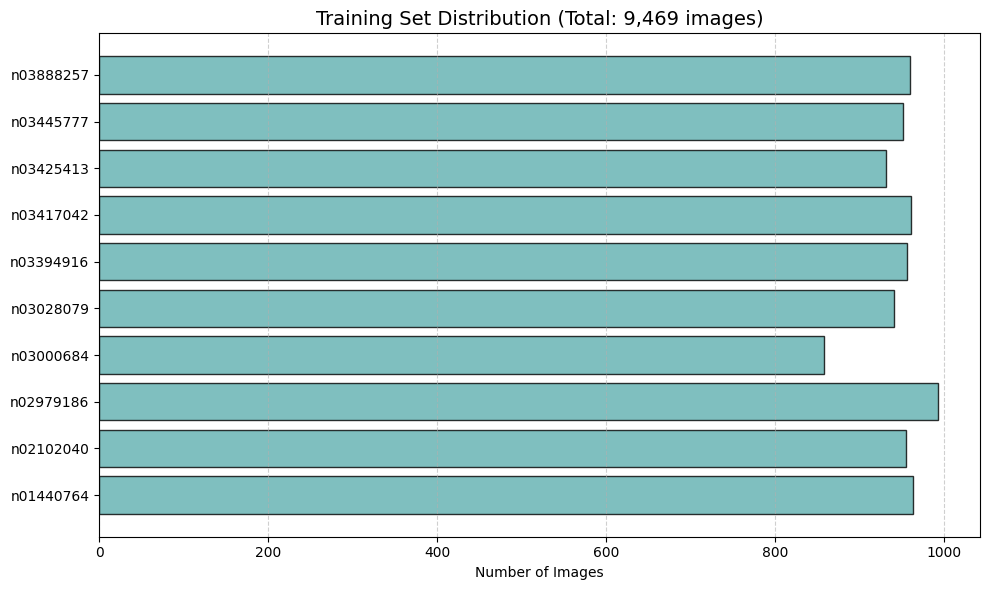


--- 正在隨機抽取每類代表圖片 ---


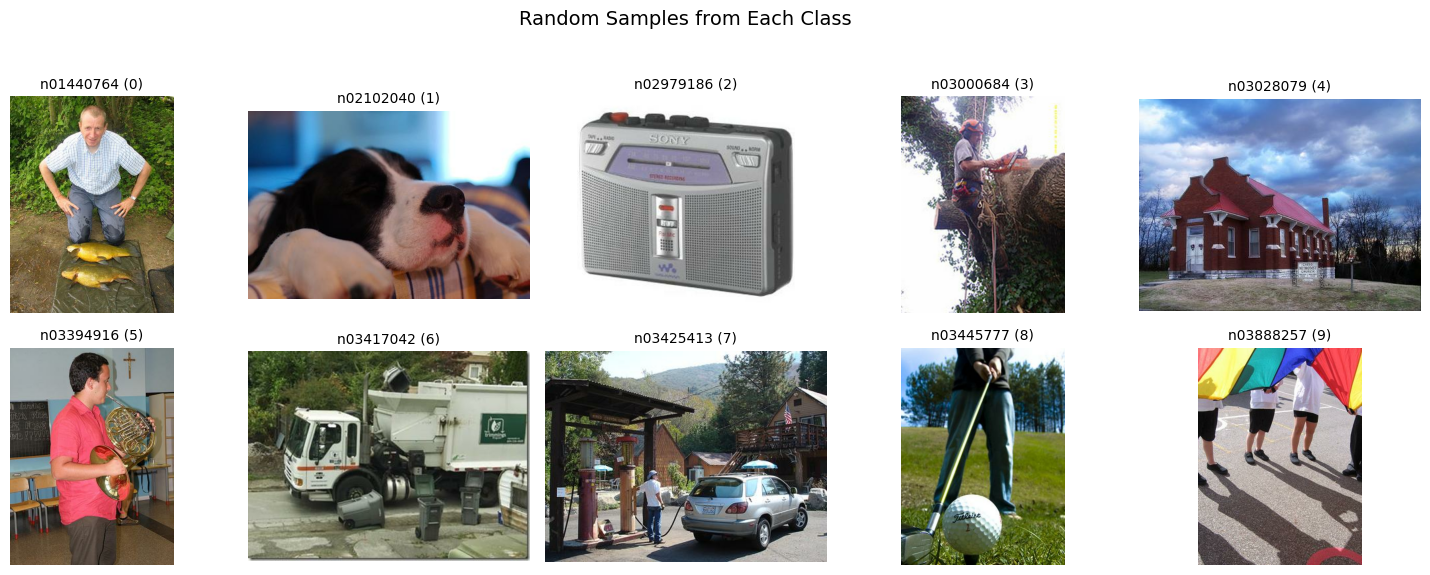

MobileNet 資料管線已就緒


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import collections
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ===================================================
# 2.1 定義預處理與增強函數
# ===================================================

def normalize_img(image, label):
    # MobileNet 建議使用 224x224 效果最佳
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    #使用函數將像素縮放至 [-1, 1]
    image = preprocess_input(image)
    return image, label

def augment(image, label):
    # 增加模型泛化能力
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

# ===================================================
# 步驟 2.2: 類別統計與隨機抽取展示
# ===================================================
print("\n--- 正在統計類別分布 ---")

# 防呆機制：自動偵測類別資訊
num_classes = ds_info.features['label'].num_classes if 'ds_info' in locals() else 10
class_names = ds_info.features['label'].names if 'ds_info' in locals() else [str(i) for i in range(10)]

# 只取 Label 進行統計，速度最快
labels_only = ds_train.map(lambda img, lbl: lbl)
all_labels = np.array(list(labels_only.as_numpy_iterator()))
counts = np.bincount(all_labels)

# 繪製橫向長條圖
plt.figure(figsize=(10, 6))
plt.barh(class_names, counts, color='#5fb0b0', edgecolor='black', alpha=0.8)
plt.title(f"Training Set Distribution (Total: {counts.sum():,} images)", fontsize=14)
plt.xlabel("Number of Images")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- 正在隨機抽取每類代表圖片 ---")
sampled_images = {}

for image, label in ds_train.shuffle(2000).take(3000):
    label_int = label.numpy()
    if label_int not in sampled_images:
        # 展示用需轉回 uint8
        sampled_images[label_int] = image.numpy().astype(np.uint8)
    
    if len(sampled_images) == num_classes:
        break

plt.figure(figsize=(15, 6))
for i in range(num_classes):
    if i in sampled_images:
        plt.subplot(2, 5, i + 1)
        plt.imshow(sampled_images[i])
        plt.title(f"{class_names[i]} ({i})", fontsize=10)
        plt.axis('off')

plt.suptitle("Random Samples from Each Class", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ===================================================
# 2.3 準備最終的訓練/驗證管線
# ===================================================
BUFFER_SIZE = tf.data.AUTOTUNE 

ds_train_pipe = (ds_train
                 .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
                 .cache() 
                 .map(augment, num_parallel_calls=BUFFER_SIZE)
                 .shuffle(buffer_size=1000) 
                 .batch(BATCH_SIZE)
                 .prefetch(BUFFER_SIZE))

ds_validation_pipe = (ds_validation
                      .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      .prefetch(BUFFER_SIZE))

print(f"MobileNet 資料管線已就緒")

In [4]:
import time
import tensorflow as tf

# ===================================================
# 3.1 自定義訓練日誌 
# ===================================================
class FullHistoryLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()
        print(f"訓練啟動時間: {time.strftime('%H:%M:%S', time.localtime())}")
        print("=" * 70)

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.epoch_start_time
        acc, val_acc = logs.get('accuracy', 0), logs.get('val_accuracy', 0)
        
        print(f"\n[Epoch {epoch + 1}] 結算: 耗時 {duration:.2f}s | Acc: {acc:.4f} | Val_Acc: {val_acc:.4f}")
        print("-" * 70)

# ===================================================
# 3.2 模型定義與編譯
# ===================================================

# 1. 載入基底模型
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False # 凍結預訓練權重

# 2. 組合模型
model = tf.keras.Sequential([
    # 加入輸入層確保結構清晰
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    # 這裡可以根據需要決定是否加入 data_augmentation 層
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(), # 加入 BatchNormalization 穩定訓練
    tf.keras.layers.Dropout(0.2),         # 防止過擬合
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# 3. 編譯模型
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nMobileNetV2 遷移學習模型已就緒！")
model.summary()

# ===================================================
# 3.3 開始訓練
# ===================================================
EPOCHS = 15
history_logger = FullHistoryLogger()

print(f"\n--- 開始訓練 (目標: {EPOCHS} 個週期) ---")

# 使用 verbose=2 讓輸出保持簡潔
history = model.fit(
    ds_train_final,
    epochs=EPOCHS,
    validation_data=ds_val_final,
    verbose=2, 
    callbacks=[history_logger] 
)

total_duration = (time.time() - history_logger.train_start_time) / 60
print(f"\n訓練全數完成，總耗時: {total_duration:.2f} 分鐘")
print(f"高驗證準確率: {max(history.history['val_accuracy']):.4f}")


MobileNetV2 遷移學習模型已就緒！
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 10)                12810     
                              


--- 訓練結果分析 ---
最低驗證損失 (Min Validation Loss): 0.0984
模型達到最佳狀態的時間 (Best Epoch): 第 15 週期。


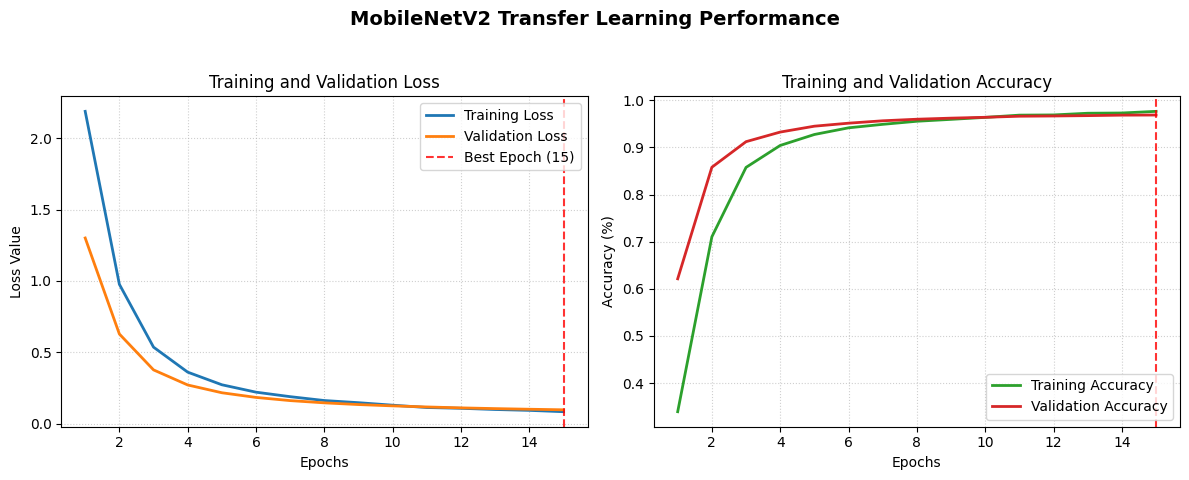

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 4.1 找出最佳時間
# ==========================================
val_loss_list = history.history['val_loss']
min_val_loss = min(val_loss_list)
# 週期從 1 開始計數
best_epoch = np.argmin(val_loss_list) + 1

print(f"\n--- 訓練結果分析 ---")
print(f"最低驗證損失 (Min Validation Loss): {min_val_loss:.4f}")
print(f"模型達到最佳狀態的時間 (Best Epoch): 第 {best_epoch} 週期。")

# ==========================================
# 4.2 繪製 Accuracy 和 Loss 曲線圖
# ==========================================
def plot_history(history, filename='mobilenet_training_report.png'):
    """繪製專業的訓練過程曲線圖。"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # X 軸從 1 開始，與 Epoch 週期對齊
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # --- 左圖：繪製 Loss 曲線 ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)
    # 紅色虛線對準 best_epoch
    plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.8, label=f'Best Epoch ({best_epoch})')
    plt.title('Training and Validation Loss', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # --- 右圖：繪製 Accuracy 曲線 ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2ca02c', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#d62728', linewidth=2)
    plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.8)
    plt.title('Training and Validation Accuracy', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle("MobileNetV2 Transfer Learning Performance", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.savefig(filename, dpi=300)
    plt.show()

# 執行繪圖
plot_history(history)
